In [3]:
import qiskit_metal as metal
from qiskit_metal import designs, draw 
from qiskit_metal import MetalGUI, Dict, open_docs 

In [4]:
design = designs.DesignPlanar() 
design.overwrite_enabled = True 

In [5]:
%metal_heading Qiskit Metal 

In [7]:
design.chips.main

{'material': 'silicon',
 'layer_start': '0',
 'layer_end': '2048',
 'size': {'center_x': '0.0mm',
  'center_y': '0.0mm',
  'center_z': '0.0mm',
  'size_x': '9mm',
  'size_y': '6mm',
  'size_z': '-750um',
  'sample_holder_top': '890um',
  'sample_holder_bottom': '1650um'}}

In [9]:
design.chips.main.size.size_x = '11mm'
design.chips.main.size.size_y = '9mm'

In [10]:
gui = MetalGUI(design)

08:35AM 37s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: Populating font family aliases took 176 ms. Replace uses of missing font family "Courier" with one that exists to avoid this cost. 



In [11]:
# Select a QComponent to create 
# Ready-made transmon qubit from QComponent library 
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

q1 = TransmonPocket(design, 'Q1', options=dict(connection_pads=dict(a=dict())))
gui.rebuild() 

gui.edit_component('Q1') # set q1 as the editable component
gui.autoscale()

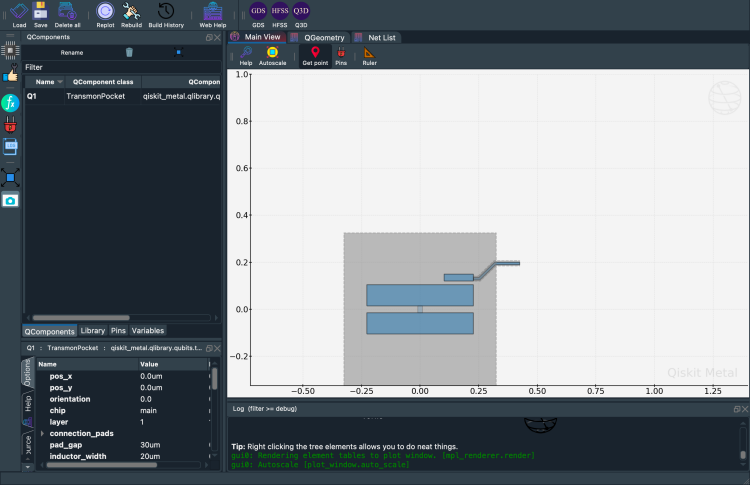

In [12]:
gui.screenshot()

In [30]:
q1

name:    Q1
class:   TransmonPocket        
options: 
  'pos_x'             : '0.5 mm',                     
  'pos_y'             : '0.25 mm',                    
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'connection_pads'   : {
       'a'                 : {
            'pad_gap'           : '15um',                       
            'pad_width'         : '125um',                      
            'pad_height'        : '30um',                       
            'pad_cpw_shift'     : '5um',                        
            'pad_cpw_extent'    : '25um',                       
            'cpw_width'         : 'cpw_width',                  
            'cpw_gap'           : 'cpw_gap',                    
            'cpw_extend'        : '100um',                      
            'pocket_extent'     : '5um',                        
            'pocket_rise'    

In [31]:
%metal_print Changing the default options

In [19]:
# Just editing the q1.options dictionary 

q1.options.pos_x = '0.5 mm'
q1.options.pos_y = '0.25 mm'
q1.options.pad_height = '225 um'
q1.options.pad_width = '250 um'
q1.options.pad_gap = '50 um'

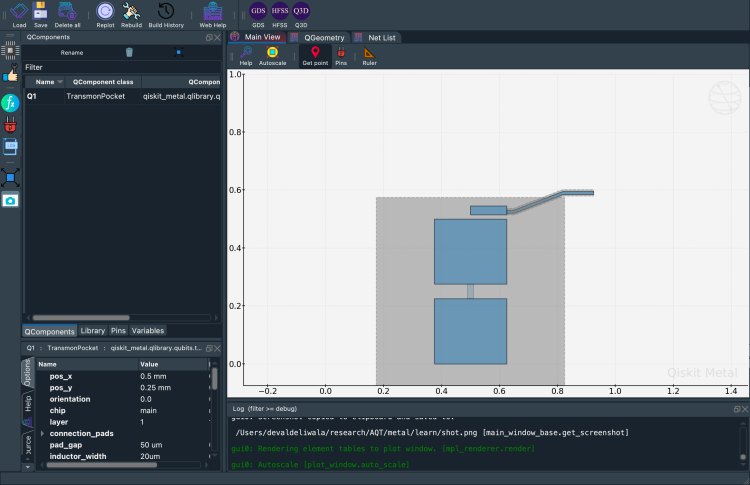

In [24]:
gui.rebuild() 
gui.autoscale()
gui.screenshot()

In [27]:
q1 = design.components['Q1'] # access q1 component among all components 

In [28]:
# finding out the default options 
TransmonPocket.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 'q3d_resistance': 0,
 'q3d_mesh_kw_jj': 7e-06,
 'gds_cell_name': 'my_other_junction',
 'aedt_q3d_inductance': 1e-08,
 'aedt_q3d_capacitance': 0,
 'aedt_hf

In [32]:
%metal_print Working with units

In [41]:
# design.parse_value or QComponent.parse_value (like q1.parse_value)

print(f'Design default units for length: {design.get_units()}')
print('Example 250 micron parse to design units:', design.parse_value('250 um'), design.get_units())

Design default units for length: mm
Example 250 micron parse to design units: 0.25 mm


In [42]:
dictionary = {'key_in_cm': '1.2 cm', 'key_in_microns': '50 um'}
print('\nExample parse dict:', design.parse_value(dictionary))


Example parse dict: {'key_in_cm': 12.0, 'key_in_microns': 0.05}


In [44]:
design.parse_value('2 * 2 um')

0.004

In [45]:
design.parse_value('2 um + 5 um')

0.007

In [46]:
design.qgeometry.tables['junction']

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (0.50000 0.22500, 0.50000 0.27500)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [49]:
%metal_heading Quantum pins: QPins. 

The component designer can define pins. Pins are used to link components together. For example, two transmons can each have a pin. The two pins can be connected by CPWs, as we will show below. 

In [50]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

In [51]:
design.delete_all_components()

First, let us add pins to the transmon. We will add 4 pins called `a`, `b`, `c` and `d`. Each pin wil be at a different location, in our case at the corner of the transmon, defined via options `loc_W` and `loc_H`. 

In [62]:
options = dict( 
    pad_width = '425 um', 
    pocket_height = '650 um', 
    connection_pads = dict( 
        a = dict(loc_W=+1, loc_H=+1), 
        b = dict(loc_W=-1, loc_H=+1, pad_height='30um'), 
        c = dict(loc_W=+1, loc_H=-1, pad_width='200um'), 
        d = dict(loc_W=-1, loc_H=-1, pad_height='50um')
    
    )
)

q1 = TransmonPocket(
    design, 
    'Q1', 
    options=dict(
        pos_x = '+0.5mm', 
        pos_y = '+0.5mm', 
        **options
    )
)

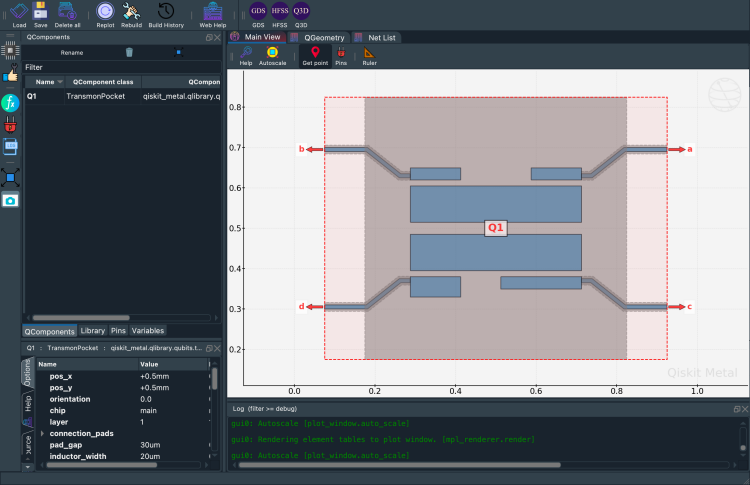

In [63]:
gui.rebuild()
gui.autoscale()
gui.edit_component('Q1')
gui.zoom_on_components(['Q1'])
gui.highlight_components(['Q1'])
gui.screenshot()

In [65]:
q1.pins['a']

{'points': [array([0.925, 0.7  ]), array([0.925, 0.69 ])],
 'middle': array([0.925, 0.695]),
 'normal': array([1., 0.]),
 'tangent': array([0., 1.]),
 'width': 0.01,
 'gap': 0.006,
 'chip': 'main',
 'parent_name': 6,
 'net_id': 0,
 'length': 0}

In [71]:
%metal_heading My First Quantum Chip

Let's now create a whole chip. In the following, you will pass options to create 4 transmon qubits in a ring. First let us clear all QComponents in the current design. 

In [82]:
design.delete_all_components()
gui.rebuild() # refresh 

In [84]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket 

design.overwrite_enabled = True 

In [85]:
options = dict( 
    pad_width = '425 um', 
    pocket_height = '650 um',
    connection_pads = dict(
        a = dict(loc_W=+1, loc_H=+1), 
        b = dict(loc_W=-1, loc_H=+1, pad_height='30um'),
        c = dict(loc_W=+1, loc_H=-1, pad_width='200um'), 
        d = dict(loc_W=-1, loc_H=-1, pad_heightt='50um'), 
    )
)

## Create 4 transmons 

q1 = TransmonPocket(design, 'Q1', options = dict(
    pos_x='+2.55mm', pos_y='+0.0mm', **options))
q2 = TransmonPocket(design, 'Q2', options = dict(
    pos_x='+0.0mm', pos_y='-0.9mm', orientation = '90', **options))
q3 = TransmonPocket(design, 'Q3', options = dict(
    pos_x='-2.55mm', pos_y='+0.0mm', **options))
q4 = TransmonPocket(design, 'Q4', options = dict(
    pos_x='+0.0mm', pos_y='+0.9mm', orientation = '90', **options))

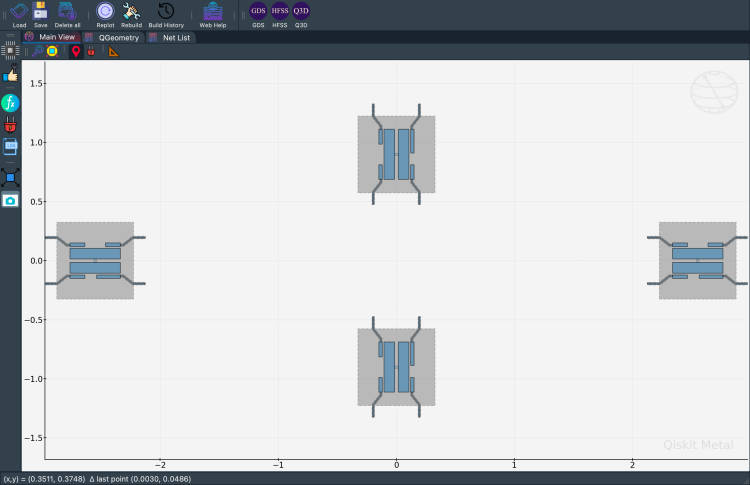

In [87]:
gui.rebuild()
gui.toggle_docks(True) # hide ugly side docks
gui.autoscale() 
gui.screenshot()

In [88]:
%metal_print Connecting the QPins with CPWs

Let's import the basic cpw QComponent from the QLibrary. It is a class called `RouteMeander`. We can see its default options using `RouteMeander.get_template_options(design)`. 

In [89]:
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander 

RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

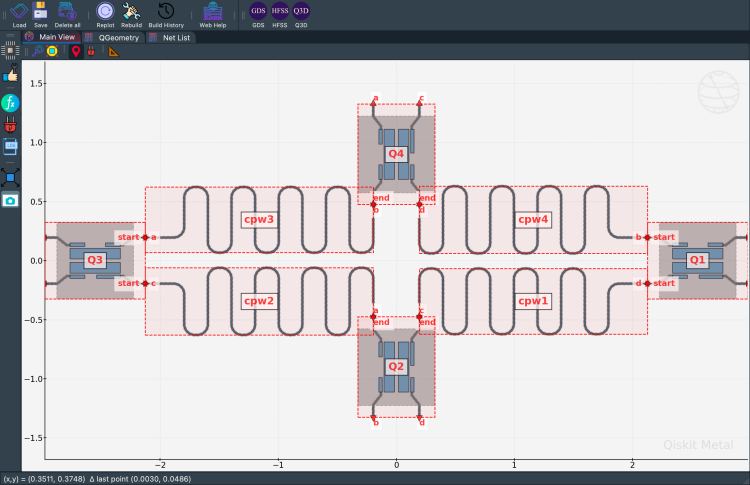

In [103]:
options = Dict(
    meander=Dict(
        lead_start='0.1mm',
        lead_end='0.1mm',
        asymmetry='0 um')
)


def connect(component_name: str, component1: str, pin1: str, component2: str, pin2: str,
            length: str,
            asymmetry='0 um', flip=False):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(
                component=component1,
                pin=pin1
            ),
            end_pin=Dict(
                component=component2,
                pin=pin2
            )
        ),
        lead=Dict(
            start_straight='0.13mm'
        ),
        total_length=length,
        fillet = '90um',
    )
    
    myoptions.update(options)
    myoptions.meander.asymmetry = asymmetry
    myoptions.meander.lead_direction_inverted = 'true' if flip else 'false'
    
    return RouteMeander(design, component_name, myoptions)

asym = 150
cpw1 = connect('cpw1', 'Q1', 'd', 'Q2', 'c', '6.0 mm', f'+{asym}um')
cpw2 = connect('cpw2', 'Q3', 'c', 'Q2', 'a', '6.1 mm', f'-{asym}um', flip=True)
cpw3 = connect('cpw3', 'Q3', 'a', 'Q4', 'b', '6.0 mm', f'+{asym}um')
cpw4 = connect('cpw4', 'Q1', 'b', 'Q4', 'd', '6.1 mm', f'-{asym}um', flip=True)

gui.rebuild()
gui.autoscale()
gui.toggle_docks(True)
gui.highlight_components(['Q1', 'Q2', 'Q3', 'Q4', 'cpw1', 'cpw2', 'cpw3', 'cpw4'])
gui.screenshot()

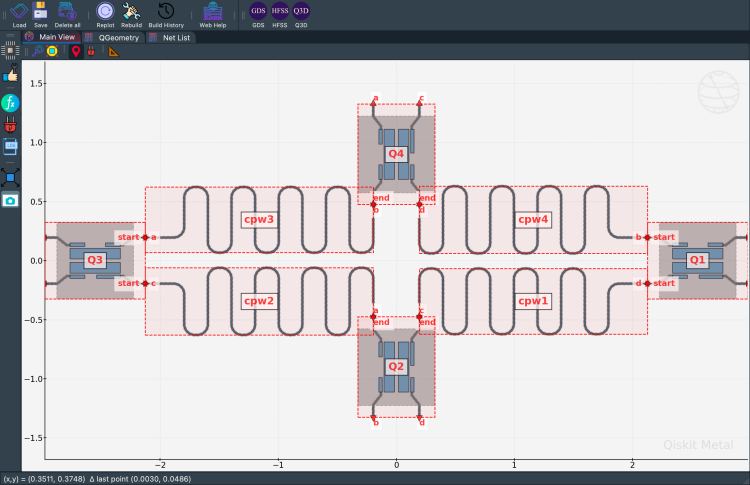

In [104]:
%metal_print Variables in options 

The design can have variables, which can be used in the component options. 

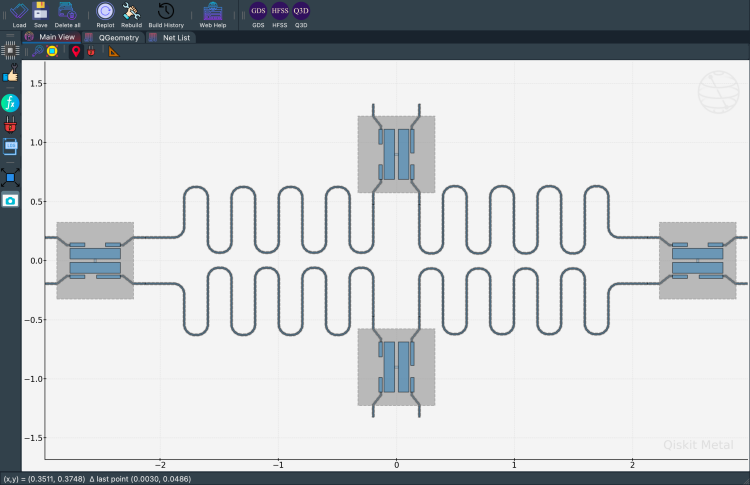

In [110]:
design.variables.cpw_width = '10um'
design.variables.cpw_gap = '6um'
gui.rebuild() 
gui.autoscale()
gui.screenshot()

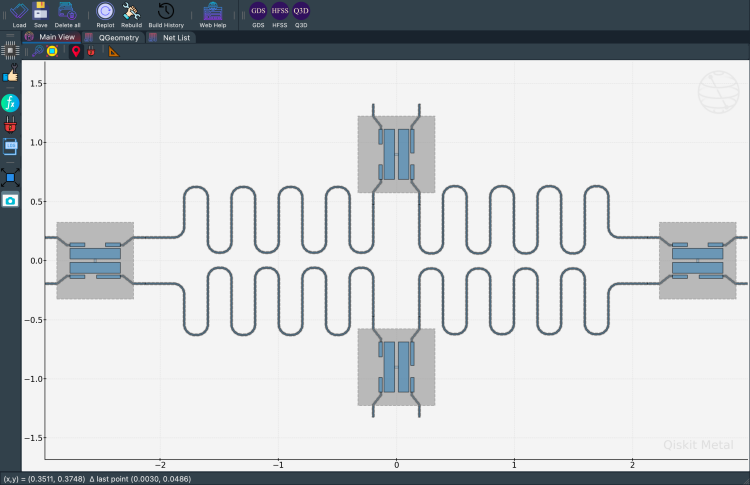

In [119]:
cpw1.options.lead.end_straight = 'um'


gui.rebuild()
gui.autoscale()
gui.screenshot()

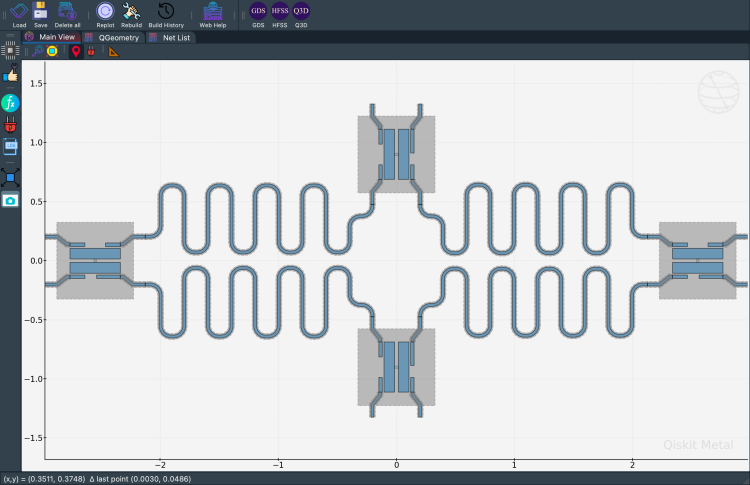

In [147]:
cpw1.options.lead.end_straight = '100um'
cpw2.options.lead.end_straight = '100um'
cpw3.options.lead.end_straight = '100um'
cpw4.options.lead.end_straight = '100um'

design.variables.pad_width = '450 um'
design.variables.cpw_width = '25 um'
design.variables.cpw_gap = '12 um'

gui.rebuild()
gui.autoscale()
gui.screenshot()

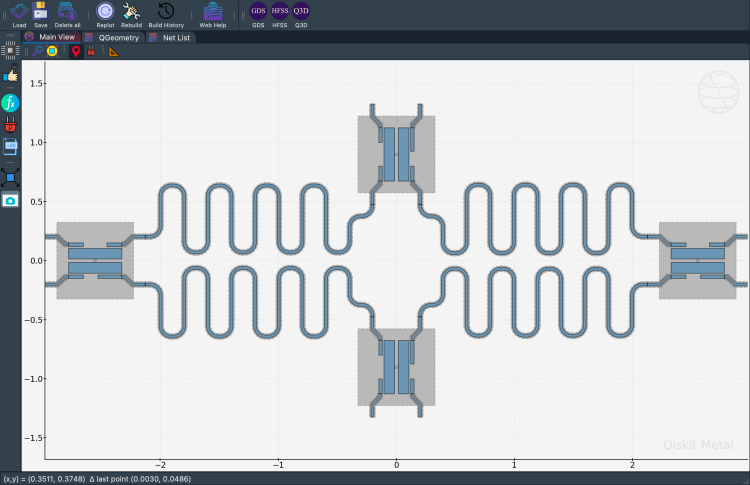

In [154]:
q1.options.pad_width = 'pad_width'
q2.options.pad_width = 'pad_width'
q3.options.pad_width = 'pad_width'
q4.options.pad_width = 'pad_width'

gui.rebuild()
gui.autoscale()
gui.screenshot()

In [155]:
%metal_heading Render to GDS

In [156]:
gds = design.renderers.gds 
gds.options.path_filename

'../resources/Fake_Junctions.GDS'

In [157]:
design.renderers.gds.export_to_gds('my_first_chip.gds')

09:35AM 44s WARNING [_import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"/Users/devaldeliwala/research/AQT/metal/resources".


1